# Problem 2

## GMM: Gaussian Mixture Models Class

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
from sklearn.datasets import load_wine
from scipy.stats import multivariate_normal, norm

# NOTE: Multiple parts of the codes were inspired from ChatGPT. Like class implementation and examples to use the inbuilt silhouette score, Kmeans etc. 

In [86]:
# Mostly inspired from ChatGPT

class GMM():
    def __init__(self, data, k):
        self.k = k
        self.likelihood = 0
        self.means=None
        self.covariances=None
        return

    def normal_multi(self, mean, cov, data):
        det = np.linalg.det(cov)
        det = np.abs(det) ** (1 / 2)
        constant = 1 / ((2 * np.pi) ** (data.shape[1] / 2) * det)
        data_mean_diff = data - mean
        exponent = -0.5 * np.sum(data_mean_diff @ np.linalg.inv(cov) * data_mean_diff, axis=1)
        return np.exp(exponent) * constant

        #     det = linalg.det(sigma)
        # if det == 0:
        #     raise NameError("The covariance matrix can't be singular")

        # norm_const = 1.0/ ( math.pow((2*pi),float(size)/2) * math.pow(det,1.0/2) )
        # x_mu = matrix(x - mu)
        # inv = sigma.I        
        # result = math.pow(math.e, -0.5 * (x_mu * inv * x_mu.T))
        # return norm_const * result

    
    
    def expectation(self, data):
        responsibilities = np.zeros((len(data), self.k))

        responsibilities = np.array([self.normal_multi(self.means[j, :], self.covariances[j], data) for j in range(self.k)]).T

        sum_prob = np.sum(responsibilities, axis=1, keepdims=True)
        responsibilities /= sum_prob

        self.responsibilities = responsibilities
        return

    def maximization(self, data, responsibilities):
        means = self.means
        covariances = self.covariances
        k = self.k
        prior_prob = self.prior_prob
        Nk = np.sum(responsibilities, axis=0)
        sum_loop = np.dot(responsibilities.T, data)
        means = sum_loop / Nk[:, np.newaxis]

        data_minus_means = data[:, np.newaxis, :] - self.means
        covariances = np.sum((responsibilities[:, :, np.newaxis, np.newaxis] * data_minus_means[:, :, :, np.newaxis]) @ data_minus_means[:, :, np.newaxis, :], axis=0) / Nk[:, np.newaxis, np.newaxis]
        for j in range(k):
            covariances[j] += 1e-8 * np.eye(data.shape[1])
            
        prior_prob = Nk / len(data)
        return covariances, means, prior_prob


    def preprocess(self, data):
        n = data.shape[0]
        visited = np.zeros(n)
        clusters_num = 0

        prior_prob = np.zeros(self.k)
        # np.random.seed(60)
        means = np.random.rand(self.k, data.shape[1])
        covariances = []
        for i in range(self.k):
            covariance = np.cov(np.transpose(data))
            covariances.append(covariance)

        while clusters_num < self.k:
            index = np.random.randint(n)
            if (visited[index]):
                continue
            prob = np.random.random()
            prior_prob[clusters_num] = prob
            clusters_num += 1
        sum = np.sum(prior_prob)
        prior_prob = prior_prob / sum

        self.prior_prob = prior_prob
        self.means = means
        self.covariances = covariances
        return


    def fit(self, data):       # Routine to fit data 
        self.preprocess(data)
 
        while not self.log_likelihood(data):
            self.expectation(data)
            self.covariances, self.means, self.prior_prob = self.maximization(data, self.responsibilities)
        return
    
    def get_parameters(self):    # Routine to obtain the parameters
        return self.means, self.covariances, self.prior_prob

    def log_likelihood(self, data):    # Routine to calculate the likelihoods for a given set of samples

        weighted_normals = np.zeros((len(data), self.k))
        for j in range(self.k):
            weighted_normals[:, j] = self.prior_prob[j] * self.normal_multi(self.means[j, :], self.covariances[j], data)

        sum_weighted_normals = np.sum(weighted_normals, axis=1)
        log_like = np.sum(np.log(sum_weighted_normals))

        if np.isclose(self.likelihood, log_like, atol=1e-5):
            self.likelihood = log_like
            return True

        self.likelihood = log_like
        return False
    

    def predict(self):    # Routine to obtain the membership values of data samples
        return np.argmax(self.responsibilities, axis = 1)
         

## Cutomer Dataset

In [87]:
df = pd.read_csv('./SMAI-Dataset-customer-dataset/data.csv')
df

,Index,Gender,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,0,67,2,124670,1,2
1,1,1,1,22,1,150773,1,2
2,2,0,0,49,1,89210,0,0
3,3,0,0,45,1,171565,1,1
4,4,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...,...
1995,1995,1,0,47,1,123525,0,0
1996,1996,1,1,27,1,117744,1,0
1997,1997,0,0,31,0,86400,0,0
1998,1998,1,1,24,1,97968,0,0


In [88]:
print("Unique Indices: ", df['Index'].unique())
print("Unique Gender: ", df['Gender'].unique())
print("Unique Marital status: ", df['Marital status'].unique())
print("Unique Age: ", df['Age'].unique())
print("Unique Education: ", df['Education'].unique())
print("Unique Incomes: ", df['Income'].unique().shape)
print("Unique Occupations: ", df['Occupation'].unique())
print("Unique Settlement size: ", df['Settlement size'].unique())

df.drop(columns=['Index', 'Income'], inplace=True)
df

Unique Indices:  [   0    1    2 ... 1997 1998 1999]
Unique Gender:  [0 1]
Unique Marital status:  [0 1]
Unique Age:  [67 22 49 45 53 35 61 28 25 24 60 32 44 31 48 26 36 39 42 34 63 27 30 57
 33 37 58 23 29 52 50 46 51 41 40 66 47 56 54 20 21 38 70 65 74 68 43 55
 64 75 19 62 59 73 72 76 71 18]
Unique Education:  [2 1 0 3]
Unique Incomes:  (1982,)
Unique Occupations:  [1 0 2]
Unique Settlement size:  [2 0 1]


,Gender,Marital status,Age,Education,Occupation,Settlement size
0,0,0,67,2,1,2
1,1,1,22,1,1,2
2,0,0,49,1,0,0
3,0,0,45,1,1,1
4,0,0,53,1,1,1
...,...,...,...,...,...,...
1995,1,0,47,1,0,0
1996,1,1,27,1,1,0
1997,0,0,31,0,0,0
1998,1,1,24,1,0,0


As the data is already quantitative, we don't need to make any more changes to it. <br>
We can drop the index and income column as they have many unique values. So, won't help in classification. 

### Finding the parameters of GMM

### Varying the number of components

In [89]:
from sklearn.metrics import silhouette_score

score = []
for comp in range(1, 10):
    data = np.array([file])
    data = np.reshape(data, (data.shape[1], data.shape[2]))
    
    gmm = GMM(data, comp)
    gmm.fit(data)
    means, covariances, prior_prob = gmm.get_parameters()
    
    print("For component = ", comp)
    print("Mean is: \n", means)
    print("Covariance is: \n", covariances)


For component =  1
Mean is: 
 [[9.99500000e+02 4.57000000e-01 4.96500000e-01 3.59090000e+01
  1.03800000e+00 1.20954419e+05 8.10500000e-01 7.39000000e-01]]
Covariance is: 
 [[[ 3.33333250e+05  9.44100000e+01  2.14777500e+01 -5.76650000e+02
    4.34250000e+00 -6.66974633e+06 -1.07614750e+02 -1.77490000e+02]
  [ 9.44100000e+01  2.48151010e-01  1.41099500e-01 -1.06741300e+00
    7.31340000e-02 -3.70369798e+03 -6.43985000e-02 -1.21723000e-01]
  [ 2.14777500e+01  1.41099500e-01  2.49987760e-01 -1.24881850e+00
    1.12133000e-01 -1.40064303e+03 -9.41325000e-03 -3.94135000e-02]
  [-5.76650000e+02 -1.06741300e+00 -1.24881850e+00  1.37275719e+02
    4.59895800e+00  1.52044747e+05  8.10755500e-01  1.13974900e+00]
  [ 4.34250000e+00  7.31340000e-02  1.12133000e-01  4.59895800e+00
    3.59556010e-01  5.33347408e+03  2.47010000e-02  1.69180000e-02]
  [-6.66974633e+06 -3.70369798e+03 -1.40064303e+03  1.52044747e+05
    5.33347408e+03  1.45155638e+09  1.65487689e+04  1.51923609e+04]
  [-1.07614750e+0

## Wine Dataset

### Find the optimal number of clusters for GMM using BIC and AIC

In [90]:
dataset = load_wine()

data = np.array([dataset['data']])
data = data.reshape(data.shape[1], data.shape[2])

target = np.array([dataset['target']])
target = target[0]

# bic = -2 * gmm.likelihood + np.log(target.shape[0]) * num_parameters
# aic = -2 * gmm.likelihood + 2 * num_parameters

aic_scores = []
bic_scores = []

for i in range(1, target.shape[0]+1):
    gmm = GMM(data, i)
    gmm.fit(data)
    num_parameters =  data.shape[1] * (data.shape[1]+1)
    num_parameters *= gmm.k/2
    num_parameters += (gmm.k - 1) + gmm.k * data.shape[1]
    
    bic = -2 * gmm.likelihood + (np.log(target.shape[0]) * num_parameters)
    aic = -2 * gmm.likelihood + 2 * num_parameters
    
    aic_scores.append(aic)
    bic_scores.append(bic)

aic_scores = np.array(aic_scores)
bic_scores = np.array(bic_scores)

print("AIC Scores: \n", aic_scores)
print("BIC Scores: \n", bic_scores)
print("\n")
print("Optimal Number of Clusters acc. to AIC: ", np.argmin(aic_scores)+1)
print("Optimal Number of Clusters acc. to BIC: ", np.argmin(bic_scores)+1)

AIC Scores: 
 [ 6870.09942517  6809.67422313  5936.59844879  5332.68197546
  5523.29390721  5088.23176021  4658.33144897  4518.30948502
  4130.04326266  5670.54972352  3709.20302149  5059.09898936
  2210.47562282  1535.62910121  4023.84789544  2975.988511
   242.89162742  3078.20158939  4295.02428914  2291.10278293
    82.54408118  2200.29075417  2186.6504739   -232.08042769
 -1240.21875527  2755.87272276  1547.88066685  4725.73658804
   501.71384923  2622.84198868  1260.14509034  -384.18805006
  3372.12628824  1373.21285434 -2868.91853936 -2243.83786038
   868.26183826  -443.39652935  2361.41971035 -2627.94431079
 -2083.27251108  1620.83668391  2201.75505498 -5484.83214207
 -2453.31491332  1446.18341032 -9458.38561286 -2547.50272814
 -4698.36145084 -2778.99519299   -13.72554359  5162.60783242
  -215.02862778 -7193.61145297 -6514.5588984  -8321.97546781
 -1314.67696378  -153.01717518 -3687.47031657 -3088.17083204
   -81.03133704 11651.63583485 -1762.68275615  2753.32738975
 -4282.95317

Text(0, 0.5, 'BIC')

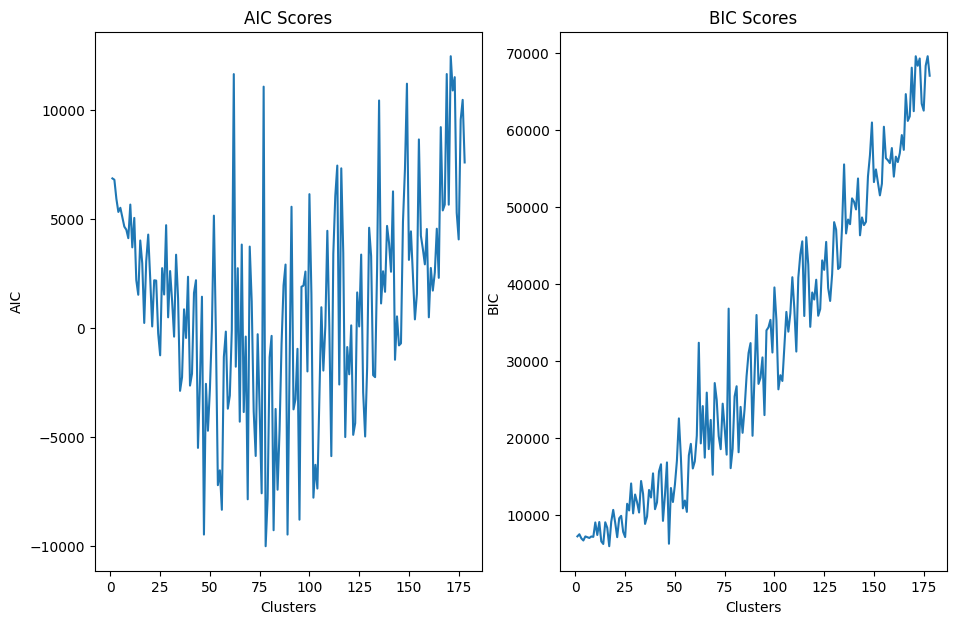

In [91]:

num_clusters = list(range(1, target.shape[0] + 1))

plt.figure(figsize=(11, 7))

plt.subplot(1, 2, 1)
plt.plot(num_clusters, aic_scores)
plt.title('AIC Scores')
plt.xlabel('Clusters')
plt.ylabel('AIC')

plt.subplot(1, 2, 2)
plt.plot(num_clusters, bic_scores)
plt.title('BIC Scores')
plt.xlabel('Clusters')
plt.ylabel('BIC')


### Reducing the dataset dimension to 2 using PCA 

In [92]:
from sklearn.decomposition import PCA

# Centering the data. 
mean = np.mean(data, axis=0)
std = np.std(data, axis=0)
data = (data-mean)/std

pca = PCA(n_components = 2)
data_centred = pca.fit_transform(data)
print(data_centred.shape)

(178, 2)


### Clustering using Gaussian Mixture Model (GMM) and K-Means algorithms.

In [93]:
from sklearn.cluster import KMeans

gmm = GMM(data_centred, np.argmin(aic_scores))
gmm.fit(data_centred)
gmm_labels = gmm.predict()
print("Labels using GMM: ")
print(gmm_labels)

print("\n")
kmeans = KMeans(n_clusters=np.argmin(aic_scores), random_state = None, n_init="auto").fit(data_centred)
kmeans_labels = kmeans.labels_
print("Lables using K Means: ")
print(kmeans_labels)

Labels using GMM: 
[14 43 23 67 28 60 31 36 15 66 14 68 70 47 25 58 42 36 69 21 43 29 22 76
 24 28 68 29 70 63 31  9 76 36 28 63 28 29 34 58 22 32 47 32 24  5  2 44
 21 67 66 44 25 42 21 13 13 13 69 33 17 52 16 10 74 34 10  6 39 11 54 76
 16 20 29 46 71  0 34 55 46 27 51 40 27  6  0 51 17 46 33 73 73 30 10 20
 54 30 45 10 30 51  3 71 30 73 74 33 71 11 45 41 54 51 41  0 46 41 73 51
 45 68 52 39 27 62 16  0 41 17 53 50 37 38 57 18 61 61 18 50 56 38 56 35
 53  8 49  7 64 72 75 48  4 72  8 59  1 65 65 49 40 53 18 35 49 57 75 64
 49 75 37  7 48  7 49  1 48  7]


Lables using K Means: 
[ 4 63  8 16 48 34  8 55  8 29  4 70 25  4 39 23 23 55 16 38 29 73  0 19
 45 48 70  5 25 54  8 66 45 55 13 45 13 73 19 23 29 30  4 30 63 31  8 29
 38 66 56 29  4 23 38  8 66 38 34 65 21 36 12 32 27 53 32  2 60 51 36 19
 50  0 51 10 72 21 19 12 22 24 43  1 24 14 10 43 74 37 11 11 71 14 14  0
 35 14 51 52 14 43 12 37 72 71 43 21  2  6  6 68  7 43 27 59 75 68 46 43
 24 73  7 35 24 68 12 21 27 36 33 28 15 28 69 15

### Computing the silhouette scores for each clustering

In [94]:
from sklearn.metrics import silhouette_score

silhouette_score_gmm = silhouette_score(data_centred, labels_gmm)
silhouette_score_kmeans = silhouette_score(data_centred, labels_kmeans)

print("The Silhouette Scores using GMM are: ", silhouette_score_gmm)
print("The Silhouette Scores using K Means are: ", silhouette_score_kmeans)

The Silhouette Scores using GMM are:  -0.07771514596195386
The Silhouette Scores using K Means are:  0.36935915459941776


### Plotting scatter plots for each of the clustering

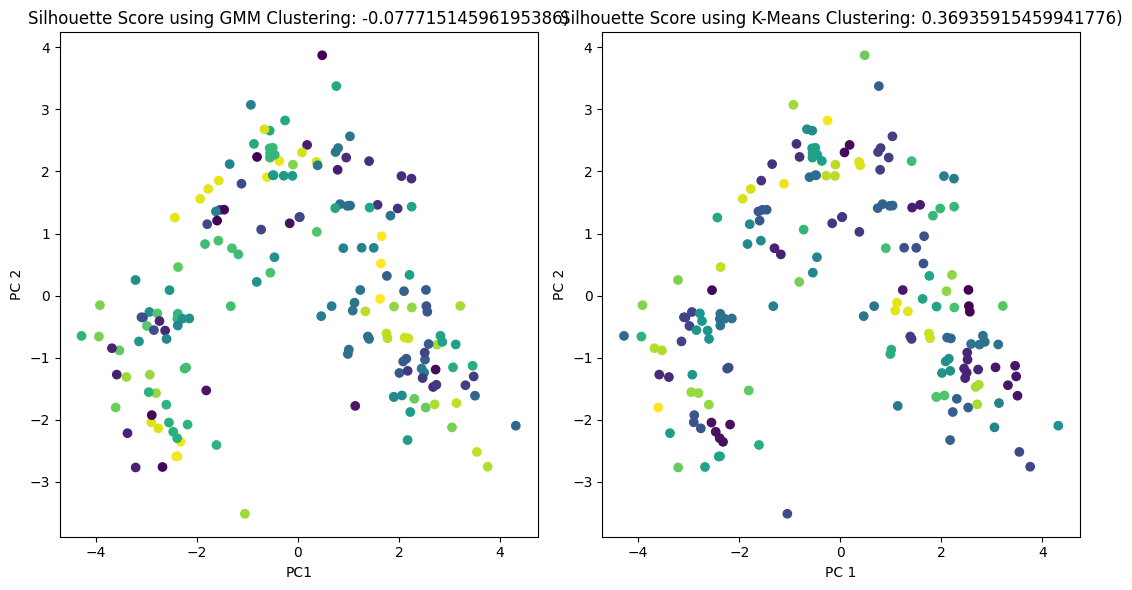

In [95]:

plt.figure(figsize=(11, 6))

plt.subplot(1, 2, 1)
plt.scatter(data_centred[:, 0], data_centred[:, 1], c=gmm_labels)
plt.title("Silhouette Score using GMM Clustering: {})".format(silhouette_score_gmm))
plt.xlabel('PC1')
plt.ylabel('PC 2')

plt.subplot(1, 2, 2)
plt.scatter(data_centred[:, 0], data_centred[:, 1], c=kmeans_labels)
plt.title("Silhouette Score using K-Means Clustering: {})".format(silhouette_score_kmeans))
plt.xlabel('PC 1')
plt.ylabel('PC 2')

plt.tight_layout()
plt.show()


AIC and BIC helps to select the number of components (clusters) in GMM. 
The model with the lowest AIC or BIC is often considered the best choice in terms of trade-off between model fit and complexity.

Silhouette Score can be used to assess the quality of clustering achieved by your GMM. 
After selecting the number of components using AIC or BIC, we can calculate the Silhouette Score to evaluate, 
how well the data points are assigned to clusters. 
A higher Silhouette Score suggests better clustering.
